<a href="https://colab.research.google.com/github/EvanChristensenUNT/CSCE1015/blob/main/Assignment3A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usa

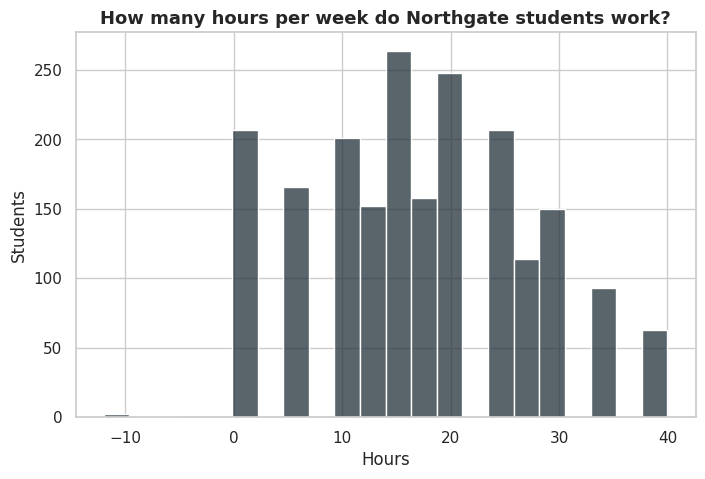

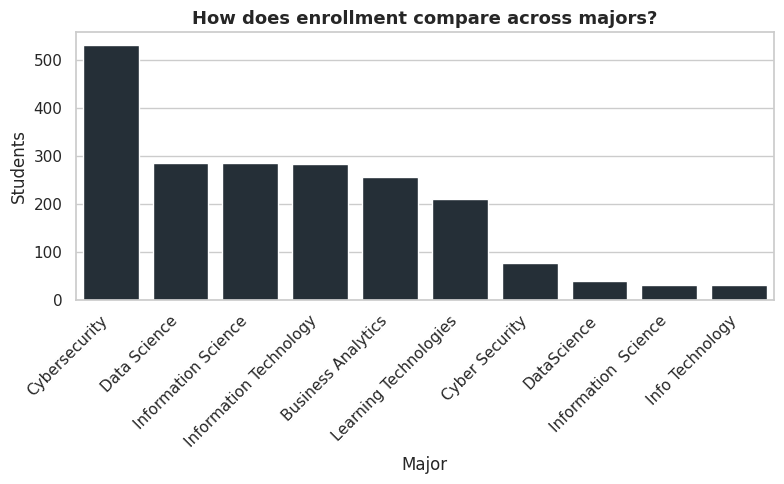

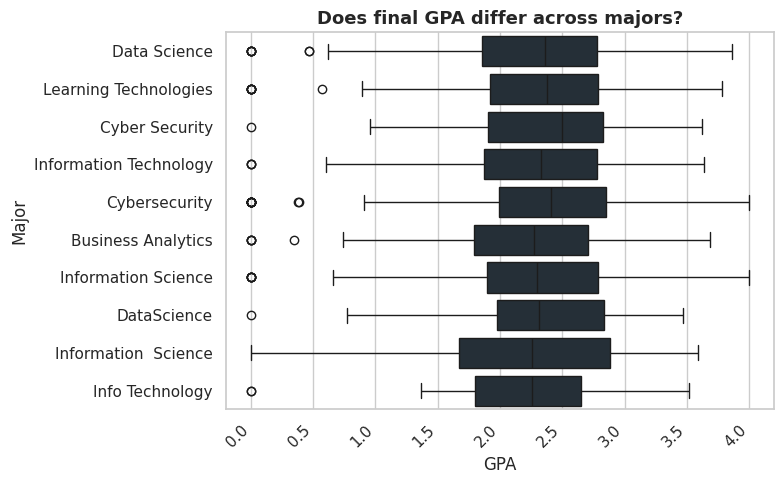

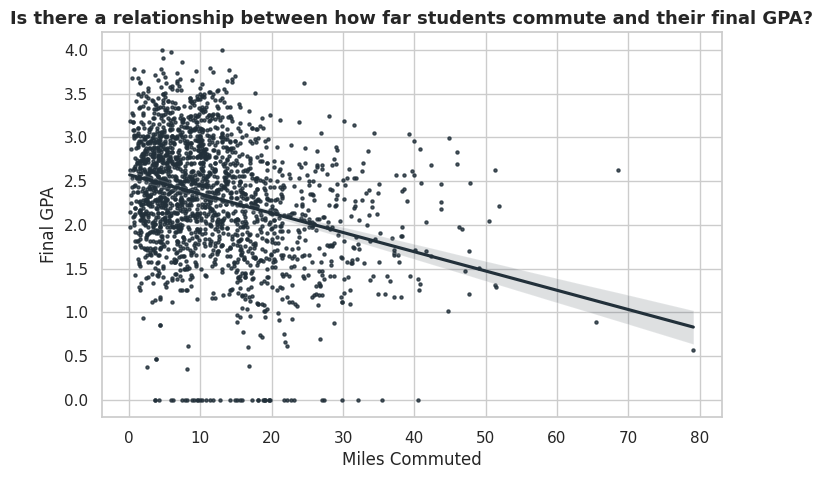

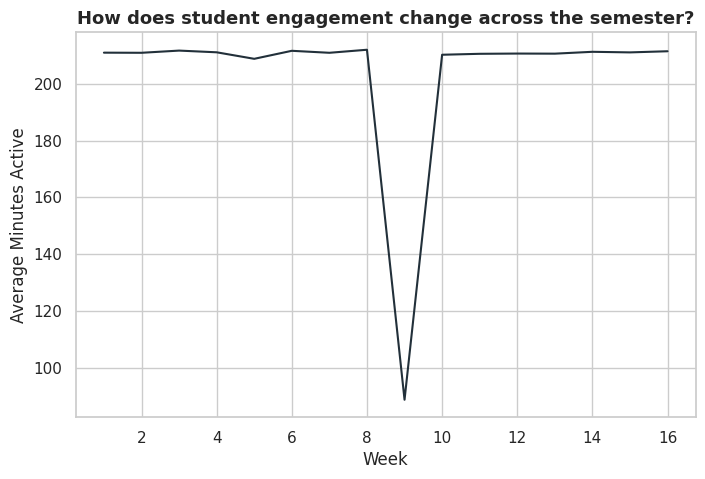

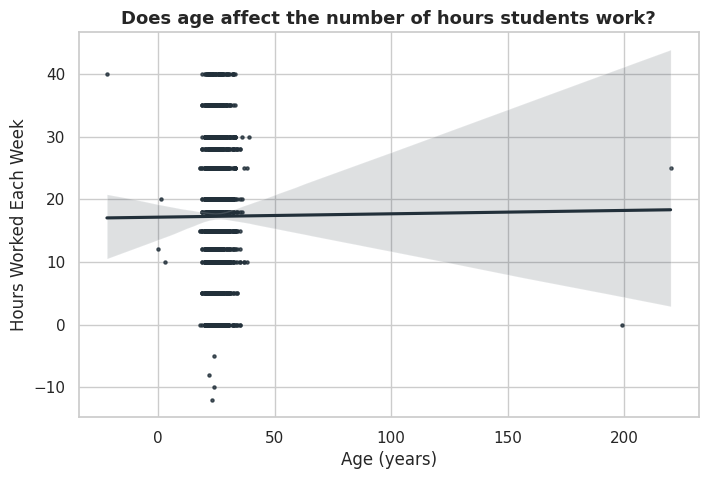

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

#DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
from google.colab import drive
drive.mount("/content/drive")
DATA_DIR = "/content/drive/MyDrive/Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

# how many rows, which columns, what types?
students.info()

#Question 1
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("How many hours per week do Northgate students work?")
ax.set_xlabel("Hours")
ax.set_ylabel("Students")
plt.show()

#STAR:
"""
S: The chart shows how many hours Northgate students work a week, including all students
T: How many hours per week do Northgate students work, on average?
A: The chart shows that students mostly work 10-20 hours, with some working as much as 40, and plenty not working at all
R: There appears to be a student that works -10 hours a week, which is likely an error
"""

#Question 2
descending_order = students["major"].value_counts().index
fig, ax = plt.subplots()
sns.countplot(data=students, x="major", color=NAVY, ax=ax, order = descending_order)   # which chart? which column(s)?
ax.set_title("How does enrollment compare across majors?")
ax.set_xlabel("Major")
ax.set_ylabel("Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#STAR:
"""
S: The chart shows how many students are enrolled in each major
T: How does enrollment compare across majors?
A: The chart shows that cybersecurity and information science has the highest amount of enrollments, with learning technology having the lowest
R: The labels for enrollment are inconsistent, and are spelled different ways leading to them not matching
"""

#Question 3

fig, ax = plt.subplots()
sns.boxplot(data=students, y="major", x = "final_gpa", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("Does final GPA differ across majors?")
ax.set_xlabel("GPA")
ax.set_ylabel("Major")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#STAR:
"""
S: The chart shows the GPAs across different majors, including outliers and quartiles
T: Does final GPA differ across majors?
A: The chart shows that cybersecurity and information science have the highest outliers, but overall the average between majors is fairly consistent
R: The labels for enrollment are inconsistent, and are spelled different ways leading to them not matching, and there seems to be some GPAs of 0, which I don't believe is possible
"""

#Question 4

fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, ax=ax,scatter_kws={"s": 5})   # which chart? which column(s)?
ax.set_title("Is there a relationship between how far students commute and their final GPA?")
ax.set_xlabel("Miles Commuted")
ax.set_ylabel("Final GPA")
plt.show()

#STAR:
"""
S: The chart shows how many miles students commute, and their final GPA
T: Is there a relationship between how far students commute and their final GPA?
A: The chart shows that most students commute 20 miles or less, with a wide range of GPAs. It doesn't appear that the commute distance affects the GPA unless it is an extreme distance, in which case GPA is affected negatively
R: There are still many students with a final GPA of 0, and the distance that some students travel is a little bit hard to believe for me, but still completely within the realm of possibility
"""

#Question 5
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y = "minutes_active", color=NAVY, ax=ax)   # which chart? which column(s)?
ax.set_title("How does student engagement change across the semester?")
ax.set_xlabel("Week")
ax.set_ylabel("Average Minutes Active")
plt.show()

#STAR:
"""
S: The chart shows how many the average minutes active for students throughout the semester
T: How does student engagement change across the semester?
A: The chart shows a fairly consistent activity level before a drop off midway through the year, most likely because of winter break
R: Everything seems to be fairly in order to me
"""

#My Question

fig, ax = plt.subplots()
sns.regplot(data=students, x="age", y="work_hours_per_week", color=NAVY, ax=ax,scatter_kws={"s": 5})   # which chart? which column(s)?
ax.set_title("Does age affect the number of hours students work?")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Hours Worked Each Week")
plt.show()

#STAR:
"""
S: The chart shows the amount of hours worked by a student each week as well as their age
T: Does age affect the number of hours students work?
A: Overall, the number of hours worked seems to be detatched from the students' ages, with maybe a slight trend of more hours for older folks
R: It seems we have some vampires at Northgate
"""
